In [1]:
!pip install -q datasets scikit-learn xgboost

from datasets import load_dataset
import pandas as pd

ds = load_dataset("Yelp/yelp_review_full")
train = pd.DataFrame(ds["train"].shuffle(seed=42).select(range(20000)))
test = pd.DataFrame(ds["test"].shuffle(seed=42).select(range(5000)))

print(train.shape, test.shape)
print(train["label"].value_counts().sort_index())
print(train["text"].str.split().str.len().describe())
print(train.head())

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

(20000, 2) (5000, 2)
label
0    3997
1    3994
2    3899
3    4038
4    4072
Name: count, dtype: int64
count    20000.000000
mean       133.496350
std        119.334707
min          1.000000
25%         52.000000
50%         99.000000
75%        176.000000
max       1034.000000
Name: text, dtype: float64
   label                                               text
0      4  I stalk this truck.  I've been to industrial p...
1      2  who really knows if this is good pho or not, i...
2      4  I LOVE Bloom Salon... all of their stylist are...
3      0  We were excited to eat here, it is difficult t...
4      2  So this is a place, with food. That much canno...


<Axes: title={'center': 'Star rating distribution (0 = 1 star)'}, xlabel='label'>

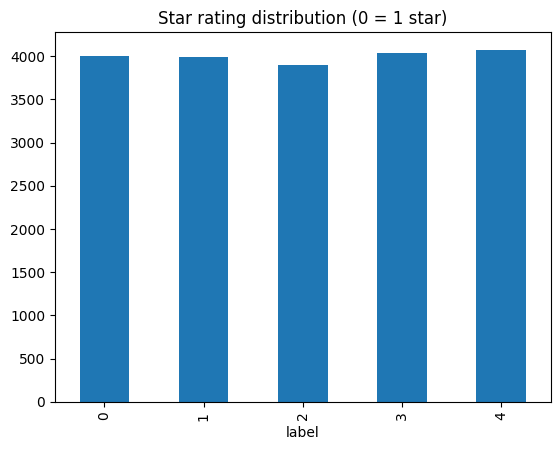

In [2]:
train["label"].value_counts().sort_index().plot(kind="bar", title="Star rating distribution (0 = 1 star)")

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score

vec = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_train = vec.fit_transform(train["text"])
X_test = vec.transform(test["text"])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, train["label"])
pred = lr.predict(X_test)

print(classification_report(test["label"], pred, target_names=["1★", "2★", "3★", "4★", "5★"]))
print("Accuracy:", accuracy_score(test["label"], pred))
print("Macro F1:", f1_score(test["label"], pred, average="macro"))

              precision    recall  f1-score   support

          1★       0.69      0.72      0.70      1032
          2★       0.50      0.50      0.50       986
          3★       0.47      0.44      0.45       974
          4★       0.50      0.47      0.49      1055
          5★       0.63      0.69      0.66       953

    accuracy                           0.56      5000
   macro avg       0.56      0.56      0.56      5000
weighted avg       0.56      0.56      0.56      5000

Accuracy: 0.5632
Macro F1: 0.5604260875378891


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, train["label"])
rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(test["label"], rf_pred))
print("RF Macro F1:", f1_score(test["label"], rf_pred, average="macro"))

RF Accuracy: 0.501
RF Macro F1: 0.48791602164949766


In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    tree_method="hist", device="cuda", random_state=42
)
xgb.fit(X_train, train["label"])
xgb_pred = xgb.predict(X_test)

print("XGB Accuracy:", accuracy_score(test["label"], xgb_pred))
print("XGB Macro F1:", f1_score(test["label"], xgb_pred, average="macro"))

XGB Accuracy: 0.5202
XGB Macro F1: 0.5160498101991606


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [22:10:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [6]:
results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "TF-IDF + Random Forest", "TF-IDF + XGBoost"],
    "Accuracy": [accuracy_score(test["label"], p) for p in [pred, rf_pred, xgb_pred]],
    "Macro F1": [f1_score(test["label"], p, average="macro") for p in [pred, rf_pred, xgb_pred]],
}).round(4)
print(results)

                          Model  Accuracy  Macro F1
0  TF-IDF + Logistic Regression    0.5632    0.5604
1        TF-IDF + Random Forest    0.5010    0.4879
2              TF-IDF + XGBoost    0.5202    0.5160
